In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [71]:
import math
import keyring
import itertools
from ast import literal_eval

In [25]:
# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [26]:
# read in the data
# df = pd.read_csv(data_dir + "/data_processed/tbi_merged.csv")
df = pd.read_csv("../../data_processing/tbi_cleaned.csv")
df

C:\Users\yianz\AppData\Local\Temp\ipykernel_23932\2582001599.py:3: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data_processing/tbi_cleaned.csv")


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451969,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,20.910320,20.910320,20.910320,32.363497
451970,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
451971,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
451972,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499


In [27]:
# read path geopkg data
car = gpd.read_file(data_dir + "/Data_Processed/car_trips.gpkg")
bike = gpd.read_file(data_dir + "/Data_Processed/bike_trips.gpkg")
transit = gpd.read_file(data_dir + "/Data_Processed/transit-trips.gpkg")
walk = gpd.read_file(data_dir + "/Data_Processed/walk_trips.gpkg")

In [ ]:
# preprocess bike

In [173]:
# wave 2 trips missing?
bike.trip_id.str[1:3].value_counts()

19    163693
18     90474
Name: trip_id, dtype: int64

In [ ]:
# preprocess transit

In [174]:
# some transit trips lack corresponding trip data
display(df[df["trip_id"] == '[1811541101009, 1811541101010, 1811541101011, 1811541101012]']["mode"]) # this trip is transit
display(transit[transit["trip_id"].str.contains("1811541101009")]) # can't find any transit trip containing the trip id

186    Transit
Name: mode, dtype: object

,trip_id,leg_index,start_time,end_time,origin_stop_id,origin_stop_name,destination_stop_id,destination_stop_name,route_id,route_short_name,route_long_name,route_type,leg_type,geometry,start_time_dt,end_time_dt,duration


In [ ]:
# calculate duration from star/tend times
transit["start_time_dt"] = pd.to_datetime(transit["start_time"])
transit["end_time_dt"] = pd.to_datetime(transit["end_time"])

transit["duration"] = (transit["end_time_dt"] - transit["start_time_dt"]).apply(lambda x: x.seconds / 60)

In [ ]:
# create a gdf for linked trips
agg_fns = {
    "trip_id": "first",
    "leg_index": "count",
    "start_time": "first",
    "end_time": "last",
    "origin_stop_id": "first", # throw away
    "origin_stop_name": "first",
    "destination_stop_id": "first",
    "destination_stop_name": "first",
    "route_id": "first", 
    "route_short_name": "first",
    "route_long_name": "first",
    "route_type": "first", 
    "leg_type": "first", # end throw away
    "start_time_dt": "first",
    "end_time_dt": "last",
    "duration": "sum"
}

transit_grouped = transit.dissolve(by="trip_id", aggfunc=agg_fns) # merges geometries in addition to aggregating the rest of the columns

In [ ]:
## beginning of analysis

In [28]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

In [29]:
## duration analysis

In [30]:
## overall summary statistics
df["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    451974.000000
mean         18.964511
std          21.713015
min           0.100000
25%           8.233333
50%          13.933333
75%          22.916667
95%          48.600000
max         970.516667
Name: duration, dtype: float64

(0.0, 200.0)

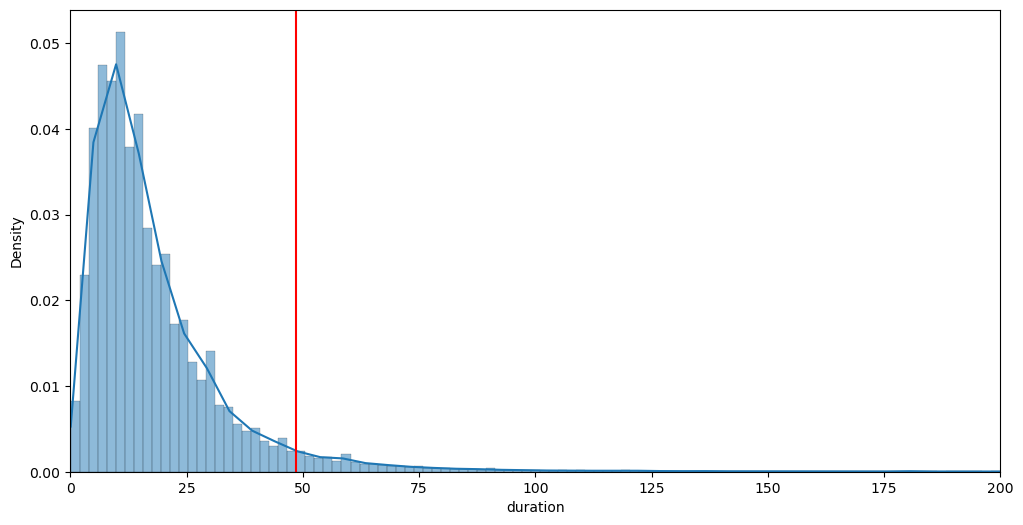

In [31]:
# overall distribution of duration
# there are repetitive peaks, likely since the temporal resolution is discrete with respect ot minutes
fig, ax = plot_density(df["duration"], bins=500)
ax.set_xlim(left=0, right=200) # cutoff upper end, there are some outliers that make the graph hard to read

Text(0.5, 0, 'log duration')

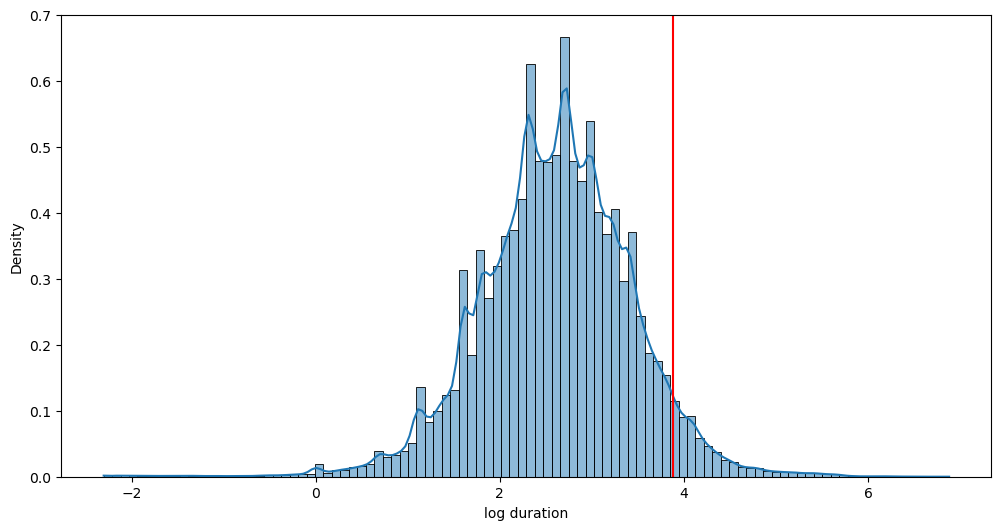

In [32]:
# overall distribution of the log of duration
fig, ax = plot_density(np.log(df["duration"]), bins=100)
ax.set_xlabel("log duration")

In [33]:
## duration analysis segmented by mode

In [34]:
df["mode"].value_counts()

Car                       377333
Walk                       50134
Transit                    11279
Bike/Scooter                7705
School bus                  3668
Taxi/Ridehail/Carshare      1855
Name: mode, dtype: int64

In [35]:
# currently ignore schools bus and taxi/ridehail/carshare -- can decide whether to omit or group with others later
# with school buses, we might need analysis for school-age children only since school buses aren't a widely available mode to the public
# with taxi/ridehail/carshare, could be transit but it is very distinct, possibly omit or add as another option
df_mode_cleaned = df[~df["mode"].isin(["School bus", "Taxi/Ridehail/Carshare"])]

In [36]:
palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
def plot_mode_density(df: pd.DataFrame, key: str, percentile=0.95, size=(12, 6), bins=300):
    fig, ax = plt.subplots(figsize=size)
    for mode in df["mode"].value_counts().index: # cycle through all modes
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(group[key], ax=ax, stat="density", kde=True, label=mode, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = group[key].quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot
    return fig, ax

In [37]:
def show_summaries(df: pd.DataFrame, key: str, percentile=0.95): # show normal summaries for each mode side by side
    res = []
    p = [0.25, 0.5, 0.75]
    p.append(percentile)
    for mode in df["mode"].value_counts().index:
        group = df[df["mode"] == mode]
        res.append(group[key].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = df["mode"].value_counts().index
    return x

In [38]:
show_summaries(df_mode_cleaned, "duration")

,Car,Walk,Transit,Bike/Scooter
count,377333.000000,50134.000000,11279.000000,7705.000000
mean,18.542229,16.149813,38.154242,23.640117
std,21.044895,18.693085,29.783879,25.802185
min,0.100000,0.100000,0.133333,0.133333
25%,8.333333,6.433333,20.000000,9.000000
50%,13.816667,11.450000,32.033333,16.083333
75%,22.350000,19.466667,48.391667,29.050000
95%,46.050000,42.200000,85.260000,66.286667
max,970.516667,325.466667,570.000000,325.800000


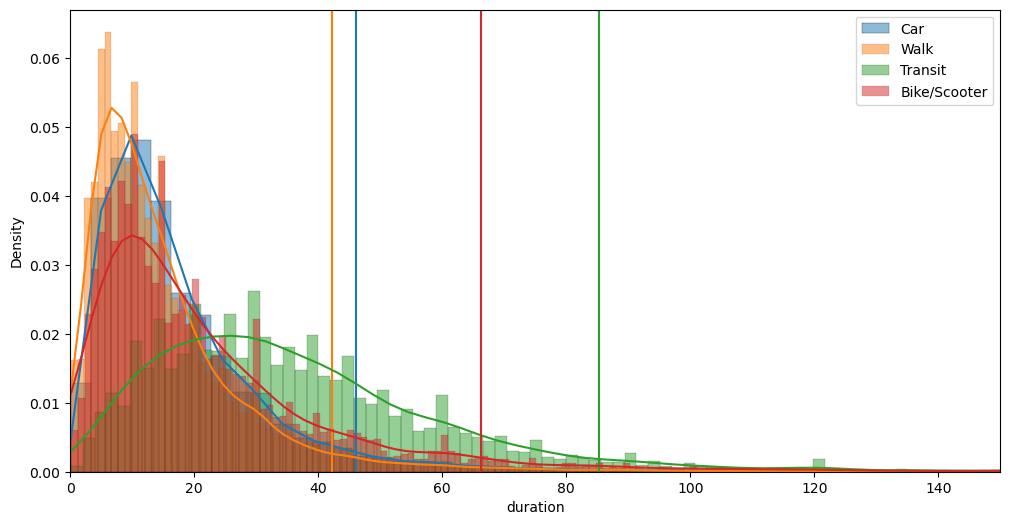

In [39]:
# plot of densities of all modes overlayed on top of one another
fig, ax = plot_mode_density(df_mode_cleaned, "duration")
ax.set_xlim(left=0, right=150)
plt.legend()

In [40]:
## difference between driving and non-driving mode durations

In [41]:
# bike vs car

In [61]:
# for each bike trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these bikers tradeoff between car & bike duration
bike_minus_car_duration = df_mode_cleaned[df_mode_cleaned["mode"] == "Bike/Scooter"]["duration"] - (car.set_index("trip_id").loc[df_mode_cleaned[(df_mode_cleaned["mode"] == "Bike/Scooter")]["trip_id"].values].duration_seconds / 60).values

In [62]:
# not sure if it would be feasible to switch to bike if car is 53 minutes faster
# self sampling likely plays a role -- maybe adopt a smaller percentile to adjust?
bike_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    7705.000000
mean       16.805448
std        23.208526
min       -11.326667
25%         5.136667
50%        10.326667
75%        19.445000
95%        53.201667
max       303.550000
Name: duration, dtype: float64

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='duration', ylabel='Density'>)

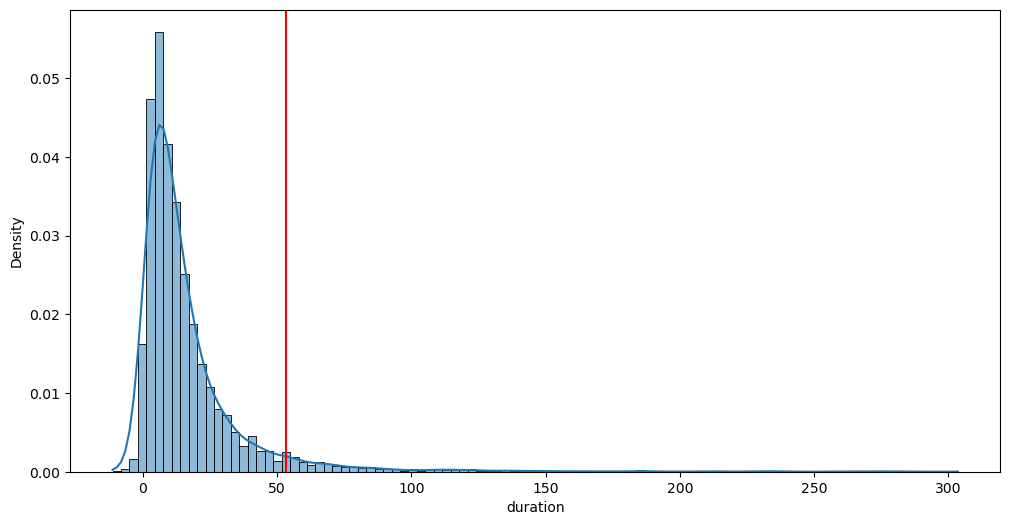

In [63]:
plot_density(bike_minus_car_duration)

In [ ]:
# transit vs car

In [166]:
# for each transit trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these transit riders tradeoff between car & transit duration

transit_minus_car_duration = df_mode_cleaned[df_mode_cleaned["mode"] == "Transit"]["duration"] - \
    (car.set_index("trip_id").loc[df_mode_cleaned[(df_mode_cleaned["mode"] == "Transit")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 200.0)

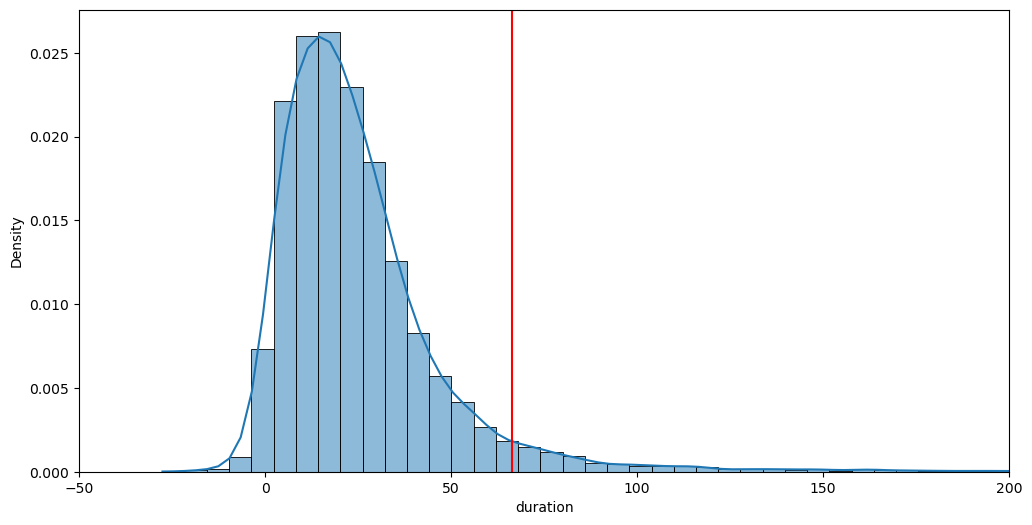

In [168]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(transit_minus_car_duration)
ax.set_xlim(left=-50, right=200)

In [172]:
transit_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    11279.000000
mean        25.941877
std         26.901623
min        -27.603333
25%         10.948333
50%         20.401667
75%         32.680000
95%         66.365333
max        570.000000
Name: duration, dtype: float64

In [88]:
# walk vs car

,trip_id,duration_seconds,distance_meters,weight,geometry
0,[1811206201001],7591.0,31387.0,7591.0,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
1,[1811206201002],7582.7,31336.2,7582.7,"LINESTRING (-92.91716 44.51007, -92.91715 44.5..."
2,[1811206203001],3692.7,15091.5,3692.7,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
3,[1811206203002],3698.1,15130.2,3698.1,"LINESTRING (-92.88609 44.73583, -92.88572 44.7..."
4,[1811206204001],3507.4,14339.8,3507.4,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
...,...,...,...,...,...
254162,[1978065201003],2919.9,11176.7,2919.9,"LINESTRING (-93.27403 44.95817, -93.27421 44.9..."
254163,[1978065201004],1692.8,6752.1,1692.8,"LINESTRING (-93.31773 44.88368, -93.31711 44.8..."
254164,[1978065201005],1441.1,5214.7,1441.1,"LINESTRING (-93.31231 44.83236, -93.31182 44.8..."
254165,[1978065202001],1862.8,6534.8,1862.8,"LINESTRING (-93.36343 44.82592, -93.36347 44.8..."


In [90]:
walk

,trip_id,duration_seconds,distance_meters,weight,geometry
0,[1811206201001],21312.0,26137.5,21312.0,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
1,[1811206201002],21312.0,26137.5,21312.0,"LINESTRING (-92.91716 44.51007, -92.91715 44.5..."
2,[1811206203001],10848.5,15066.6,10848.5,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
3,[1811206203002],10848.5,15066.6,10848.5,"LINESTRING (-92.88609 44.73583, -92.88572 44.7..."
4,[1811206204001],10290.3,14292.2,10290.3,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
...,...,...,...,...,...
458645,[2200279003003],2751.3,3821.7,2751.3,"LINESTRING (-93.14578 44.91527, -93.14603 44.9..."
458646,[2200279101001],4248.0,5894.8,4248.0,"LINESTRING (-93.38229 45.04008, -93.38164 45.0..."
458647,[2200279101002],4248.0,5894.8,4248.0,"LINESTRING (-93.35434 45.07169, -93.35359 45.0..."
458648,[2200279102001],3210.6,4453.7,3210.6,"LINESTRING (-93.38229 45.04008, -93.38289 45.0..."
